In [33]:
import os
import sys
import requests
from langchain_openai import ChatOpenAI
from openai import OpenAI
from langchain_core.tools import tool

from langchain_core.messages import HumanMessage,SystemMessage,AIMessage
from langgraph.graph import StateGraph,START,END,MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import ToolNode,tools_condition
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from typing import List,Literal,Optional,Dict,Any
from pydantic import BaseModel
from langgraph.checkpoint.memory import MemorySaver

In [34]:
sys.path.append(os.path.abspath(".."))

In [35]:
sys.path.append(os.path.abspath("../.."))

In [36]:
from src.config import get_settings
settings = get_settings()
fastapi_base_url = settings.BASE_URL

In [37]:
fastapi_base_url

'https://powerbi-n7h5.onrender.com'

In [38]:
@tool
def check_health() -> dict:

    """
    Checks the health of the Power BI API.

    This function verifies whether the Power BI service is reachable and functioning correctly
    by attempting to retrieve an access token from the configured Power BI endpoint.
    If a valid token is successfully returned, the API is considered healthy.
    """
    try:
        response = requests.get(f"{settings.BASE_URL}/health",timeout=10)
        response.raise_for_status()
        return {"status": "healthy"}

    except requests.exceptions.RequestException as e:
        return {"status": "unhealthy", "message": str(e)}
    
@tool
def compare_workspaces() -> dict:

    """
    Compares Power BI workspaces between DEV and PROD environments.

    This function identifies dashboard reports that exist in the DEV workspace
    but are missing in the PROD workspace. It also returns the total number of
    reports present in both DEV and PROD for comparison.
    """
    settings = get_settings()

    try:
        url = f"{settings.BASE_URL}/comparison"
        response = requests.get(url, timeout=15)
        response.raise_for_status()

        return {"status": "success", "data": response.json()}

    except Exception as e:
        return {
            "status": "error",
            "message": str(e)
        }
    
@tool
def recommend_dashboards(user_query: str,top_n: int = 3) -> dict:
    
    """
    Recommend the most relevant Power BI dashboards based on a user query.

    This function analyzes a natural language query and returns the top matching
    dashboards ranked by relevance.

    Args:
        user_query (str): A natural language query describing the desired analysis
            (e.g., "looking for analysis related to supply chain pillar").
        top_n (int): The number of top dashboard recommendations to return.
    """
    settings = get_settings()

    try:
        url = f"{settings.BASE_URL}/recommend"
        params = {
            "user_query": user_query,
            "top_n": top_n
        }

        response = requests.get(url, params=params, timeout=20)
        response.raise_for_status()

        return {"status": "success", "data": response.json()}

    except Exception as e:
        return {
            "status": "error",
            "message": str(e)
        }
    
@tool
def migrate_dashboard(
    dashboard_name: str,
    from_workspace_name: str,
    to_workspace_name: str
) -> dict:
    """
    Migrate a Power BI dashboard between workspaces.

    This function transfers a specified dashboard from a source workspace
    to a target workspace, typically used for promoting content from
    development (DEV) to production (PROD).

    Args:
        dashboard_name (str): Name of the dashboard to be migrated.
        from_workspace_name (str): Source workspace name (e.g., "DEV").
        to_workspace_name (str): Target workspace name (e.g., "PROD").

    Note:
        This operation should only be executed after explicit user confirmation,
        as it may impact production environments.
    """
    settings = get_settings()

    try:
        url = f"{settings.BASE_URL}/migration"

        params = {
            "dashboard_name": dashboard_name,
            "from_workspace_name": from_workspace_name,
            "to_workspace_name": to_workspace_name
        }

        response = requests.get(url, params=params, timeout=60)
        response.raise_for_status()

        return {
            "status": "success",
            "data": response.json()
        }

    except Exception as e:
        return {
            "status": "error",
            "message": str(e)
        }
    
@tool
def delete_dashboard(
    dashboard_name: str,
    workspace_name: str
) -> dict:
    """
    Deletes a Power BI dashboard and its dataset from a workspace.

    Args:
        dashboard_name: Name of the dashboard to delete
        workspace_name: Workspace where the dashboard exists

    ⚠️ WARNING: This action is irreversible. Use only after user confirmation.
    """
    settings = get_settings()

    try:
        url = f"{settings.BASE_URL}/deletion"

        params = {
            "dashboard_name": dashboard_name,
            "workspace_name": workspace_name
        }

        response = requests.get(url, params=params, timeout=30)
        response.raise_for_status()

        return {
            "status": "success",
            "data": response.json()
        }

    except Exception as e:
        return {
            "status": "error",
            "message": str(e)
        }

In [39]:
class MetaIntent(BaseModel):
    action: Literal["continue", "cancel", "new_intent"]

class ExtractionOutput(BaseModel):
    dashboard_name: Optional[str]
    source_workspace: Optional[str]
    target_workspace: Optional[str]


class AgentState(MessagesState):
    user_query: Optional[str]
    intent: Optional[str]
   
    dashboard_name: Optional[str] = None
    source_workspace: Optional[str] = None
    target_workspace: Optional[str] = None

    extracted: bool = False
    meta_action: Optional[str] = None
    is_confirmed: bool = False
    clarification_count: int = 0

class IntentOutput(BaseModel):
    intent: Literal[
        "recommend_dashboards",
        "compare_workspaces",
        "migrate_dashboard",
        "delete_dashboard",
        "ambiguous"
    ]

In [40]:
system_prompt = """
        You are a helpful assistant specialized in Power BI operations.

        Your capabilities include:
        - Recommending Power BI dashboards based on user queries
        - Migrating dashboards between workspaces (Dev → Prod)
        - Deleting dashboards from Dev and Prod workspaces
        - Comparing dashboards between Dev and Prod workspaces

        Workspace Rules:
        - Valid workspace names are "Dev" and "Prod"
        - Normalize any user input (e.g., DEV, dev, PROD, prod) to "Dev" or "Prod"

        Tool Usage Guidelines:
        - Select the most appropriate tool based on the user’s intent
        - Ensure actions like migration or deletion are clearly understood before execution

        Clarification Handling:
        - If the user query is unclear, ask up to 3 relevant clarifying questions
        - If the intent is still unclear after clarification, respond with:
        "Sorry, not able to understand."

        General Behavior:
        - Be precise, structured, and action-oriented
        - Do not assume missing details—always confirm when required

        - Always prioritize the latest user message over past context
        - If the user changes their mind or cancels an action, do NOT continue the previous intent

        """
   



In [41]:
def agent_state_node(state: AgentState) -> Dict[str, Any]:
    messages = state["messages"]

    # Extract last human message safely
    user_query = None
    for msg in reversed(messages):
        if isinstance(msg, HumanMessage):
            user_query = msg.content
            break

    return {
        "messages": messages,
        "user_query": user_query,
        "intent": state.get("intent"),
        "clarification_count": state.get("clarification_count", 0),
        "is_confirmed": state.get("is_confirmed", None),
        "extracted": state.get("extracted", False),
        "meta_action": state.get("meta_action"),
        "dashboard_name": state.get("dashboard_name"),
        "source_workspace": state.get("source_workspace"),
        "target_workspace": state.get("target_workspace")
    }


In [42]:
def meta_intent_node(state: AgentState):
    llm = ChatOpenAI(model=settings.openai_llm_model,
                     api_key=settings.OPENAI_API_KEY.get_secret_value())
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", """
            You analyze conversation flow between a user and an assistant.

            Your task is to decide whether the user's latest message:

            1. continue → continues the SAME task with more details or corrections
            2. cancel → rejects or stops the current task
            3. new_intent → starts a DIFFERENT task than before

            Guidelines:

            - Compare the user's latest request with the previous task.
            - If the TYPE OF ACTION changes (e.g., from deleting to migrating), it is a new_intent.
            - If the user is only refining details (like changing dashboard name or workspace), it is continue.
            - If the user rejects the operation entirely, it is cancel.
            - Focus on the meaning of the request, not specific words.
            - Use the full conversation context.

            Return ONLY one word:
            continue OR cancel OR new_intent
            """),
                    ("placeholder", "{messages}")
                ])
    chain = prompt | llm.with_structured_output(MetaIntent)
    result = chain.invoke({"messages": state["messages"]})
    return {"meta_action": result.action}

In [43]:
def meta_router(state: AgentState):
    return state.get("meta_action", "continue")

In [44]:
def cancel_node(state: AgentState):
    return {
        "intent": None,
        "dashboard_name": None,
        "source_workspace": None,
        "target_workspace": None,
        "extracted": False,
        "is_confirmed": False,
        "messages": state["messages"] + [
            AIMessage(content="👍 Operation cancelled. What would you like to do next?")
        ]
    }

In [45]:
def extract_entities_node(state: AgentState):
    llm = ChatOpenAI(
        model=settings.openai_llm_model,
        api_key=settings.OPENAI_API_KEY.get_secret_value()
    )

    intent = state.get("intent")
    meta_action = state.get("meta_action")

    prompt = ChatPromptTemplate.from_messages([("system", f"""
                You are an expert information extraction system for Power BI operations.
                Your task is to extract structured fields from the conversation.

                Intent: {intent}

                EXTRACTION RULES
         
                If intent = migrate_dashboard:
                - Extract:
                - dashboard_name
                - source_workspace (Dev or Prod)
                - target_workspace (Dev or Prod)

                If intent = delete_dashboard:
                - Extract:
                - dashboard_name
                - target_workspace (Dev or Prod)
                - DO NOT extract source_workspace

                GENERAL RULES
              
                1. Use FULL conversation to understand the context (not just last message)
                2. If user corrects something:
                - Update ONLY that field
                - Keep previously correct values
                3. Normalize workspace names:
                - dev, DEV → Dev
                - prod, PROD → Prod
                4. DO NOT guess values:
                - If not clear, return null
                5. Dashboard name:
                - Extract exact phrase if possible
                - Do not rephrase unnecessarily
                6. If user gives partial info:
                - Extract what is available
                - Leave others as null
                7. NEVER hallucinate missing fields

                OUTPUT

                Return structured output only.
                """),
        ("placeholder", "{messages}")
    ])

    chain = prompt | llm.with_structured_output(ExtractionOutput)
    result = chain.invoke({"messages": state["messages"]})

    if meta_action == "continue":
        dashboard = result.dashboard_name or state.get("dashboard_name")
        source = result.source_workspace or state.get("source_workspace")
        target = result.target_workspace or state.get("target_workspace")

    else:
        dashboard = result.dashboard_name
        source = result.source_workspace
        target = result.target_workspace

    return {
        "dashboard_name": dashboard,

        # 🔥 IMPORTANT LOGIC
        "source_workspace": (
            source if intent == "migrate_dashboard"
            else None
        ),

        "target_workspace": target,

        "extracted": True
    }

In [46]:
def clarification_node(state: AgentState):
    count = state.get("clarification_count", 0)

    # Stop after 3 attempts
    if count >= 3:
        return {
            "messages": state["messages"] + [
                AIMessage(content="Sorry, not able to understand.")
            ]
        }

    llm = ChatOpenAI(model=settings.openai_llm_model,api_key=settings.OPENAI_API_KEY.get_secret_value())

    prompt = ChatPromptTemplate.from_messages([
        ("system",system_prompt + "\n\n" + """You help clarify user intent for Power BI actions.

            Your goal is to ask ONE neutral and clear question to understand the user's intent.

            Guidelines:
            - Do NOT assume the user's intent
            - Do NOT suggest actions like migrate or delete unless explicitly mentioned
            - Offer clear choices instead of leading the user
            - Keep the question simple and specific """),
            ("human", "{question}")
            
        
    ])

    chain = prompt | llm | StrOutputParser()

    clarification_question = chain.invoke({
        "question": state["user_query"]   # 🔥 FULL CONTEXT
    })

    return {
        "messages": state["messages"] + [
            AIMessage(content=clarification_question)
        ],
        "clarification_count": count + 1
    }

In [47]:
def confirmation_handler(state: AgentState):
    last_msg = state["messages"][-1].content.lower()

    if last_msg in ["yes", "y"]:
        return {
            "is_confirmed": True,
             "messages": state["messages"] + [
                AIMessage(content="✅received. Executing request...")]
        }
    elif last_msg in ["no", "n"]:
        return {
            "intent": None,
            "extracted": False,
            "messages": state["messages"] + [
                AIMessage(content="❌ Operation cancelled.")
            ]
        }
    else:
        return {
            "messages": state["messages"] + [
                AIMessage(content="Please reply with 'yes' or 'no'.")
            ]
        }

In [48]:
router_prompt = """
You are an expert AI agent that classifies user intent for Power BI operations.

Your task is to understand the user's goal and classify it into ONE of the following intents:

1. recommend_dashboards  
   → User is looking for suggestions, insights, or relevant dashboards based on a topic

2. compare_workspaces  
   → User wants to understand differences, gaps, discrepancies, or missing dashboards 
     between Dev and Prod workspaces

3. migrate_dashboard  
   → User wants to move, promote, or deploy a dashboard from one workspace (Dev) to another (Prod)

4. delete_dashboard  
   → User wants to remove or delete a dashboard from a workspace

5. ambiguous  
   → The user intent is unclear, incomplete, or cannot be confidently mapped

---

Guidelines:
- Focus on the USER'S GOAL, not keywords
- Use the full conversation context
- If the user replies with short answers like "yes", "ok", infer intent from full conversation, not just last message
- Prefer compare_workspaces when the user is asking about differences, gaps, or missing items
- Only select migrate_dashboard or delete_dashboard if the user clearly intends an ACTION
- If unsure → return "ambiguous"
- Do NOT ask questions
- Do NOT explain

Return only the intent.
"""

In [49]:
def router_decision(state: AgentState):
    llm = ChatOpenAI(model=settings.openai_llm_model,
                     api_key=settings.OPENAI_API_KEY.get_secret_value())

    prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt + "\n\n" + router_prompt),
        ("placeholder", "{messages}")   # 🔥 CRITICAL
    ])


    chain = prompt | llm.with_structured_output(IntentOutput)

    response = chain.invoke({"messages": state["messages"]})

    return {
        "intent": response.intent
    }


In [50]:
def route_selector(state: AgentState):
    return state["intent"]

In [51]:
def confirmation_node(state: AgentState):

    if state.get("is_confirmed"):
        return state

    intent = state.get("intent")

    if intent not in ["migrate_dashboard", "delete_dashboard"]:
        return state

    dashboard = state.get("dashboard_name")
    source = state.get("source_workspace")
    target = state.get("target_workspace")

    # ✅ VALIDATION FIRST
    if intent == "migrate_dashboard":
        if not all([dashboard, source, target]):
            return {
                "messages": state["messages"] + [
                    AIMessage(content="""
⚠️ Missing required details for migration.

Please provide:
dashboard_name, source_workspace, target_workspace

Example:
Sales-Dashboard, Dev, Prod
""")
                ]
            }

        return {
            "messages": state["messages"] + [
                AIMessage(content=f"""
I understood your request as Migration:

- Dashboard: {dashboard}
- From: {source}
- To: {target}

👉 Reply **yes** to proceed or correct me.
""")
            ]
        }

    elif intent == "delete_dashboard":
        if not all([dashboard, target]):
            return {
                "messages": state["messages"] + [
                    AIMessage(content="""
⚠️ Missing required details for deletion.

Please provide:
dashboard_name, workspace

Example:
Sales-Dashboard, Prod
""")
                ]
            }

        return {
            "messages": state["messages"] + [
                AIMessage(content=f"""
I understood your request as Deletion:

- Dashboard: {dashboard}
- Workspace: {target}

👉 Reply **yes** to proceed or correct me.
""")
            ]
        }

In [52]:
def entry_router(state: AgentState):
    last_msg = state["messages"][-1].content.lower().strip()

    # ✅ confirmation response
    if last_msg in ["yes", "no", "y", "n"] and not state.get("is_confirmed"):
        return "confirmation"
    
    # if state.get("extracted") and not state.get("is_confirmed"):
    #     return "confirmation"

    # # ✅ input details (simple heuristic)
    # if state.get("is_confirmed"):
    #     return "router"
        
    return "router"


In [53]:
def health_check_node(state: AgentState):
    result = check_health.invoke({}) 

    if result.get("status") != "healthy":
        return {
            "messages": state["messages"] + [
                AIMessage(content="❌ Power BI API is down. Aborting request.")
            ]
        }

    return state



In [54]:
def tool_executor(state: AgentState):
    """
    Based on the User Intent, execute the appropriate tool
    """
    intent = state["intent"]
    query = state["user_query"]

    if intent == "recommend_dashboards":
        result = recommend_dashboards.invoke({
            "user_query": query,
            "top_n": 3
        })

    elif intent == "compare_workspaces":
        result = compare_workspaces.invoke({})

    elif intent == "migrate_dashboard":
        dashboard = state.get("dashboard_name")
        source = state.get("source_workspace")
        target = state.get("target_workspace")
        if not all([dashboard, source, target]):
            return {
                "messages": state["messages"] + [
                    AIMessage(content="⚠️ Missing details. Please specify dashboard, source, and target.")
                ]
            }

        result = migrate_dashboard.invoke({
            "dashboard_name": dashboard,
            "from_workspace_name": source,
            "to_workspace_name": target
        })

    elif intent == "delete_dashboard":
        dashboard = state.get("dashboard_name")
        target = state.get("target_workspace")
        if not all([dashboard,target]):
            return {
                "messages": state["messages"] + [
                    AIMessage(content="⚠️ Missing details. Please specify dashboard and target workspace.")
                ]
            }

        result = delete_dashboard.invoke({
            "dashboard_name": dashboard,
            "workspace_name": target
        })

    else:
        return {
            "messages": state["messages"] + [
                AIMessage(content="Sorry, not able to understand.")
            ]
        }

    return {
        "messages": state["messages"] + [
            AIMessage(content=str(result))
        ]
    }



In [55]:
def reset_for_new_intent(state: AgentState):
    return {
        "intent": None,
        "dashboard_name": None,
        "source_workspace": None,
        "target_workspace": None,
        "extracted": False,
        "is_confirmed": False,
        "clarification_count": 0,
        "meta_action": None
    }

In [59]:
def llm_response_node(state: AgentState):
    llm = ChatOpenAI(
        model=settings.openai_llm_model,
        api_key=settings.OPENAI_API_KEY.get_secret_value()
    )

    intent = state.get("intent")
    user_query = state.get("user_query")

    prompt = ChatPromptTemplate.from_messages([
        ("system", f"""
        You are a helpful AI assistant specialized in Power BI.

        CONTEXT:
        - Detected intent: {intent}
        - User query: {user_query}

        BEHAVIOR RULES:

        1. If the query is general conversation (hi, hello, casual talk):
        → Respond naturally like a human assistant

        2. If the query is unclear but related to Power BI:
        → Ask ONE smart clarification question

        3. If the user seems to want an action (delete/migrate/etc.) but it's incomplete:
        → Guide them with what info is missing (DO NOT execute anything)

        4. If the user is totally unrelated to Power BI:
        → Politely steer them back to supported capabilities

        5. Keep responses:
        - Short
        - Friendly
        - Action-oriented

        DO NOT:
        - Hallucinate dashboards
        - Trigger tools
        - Be overly verbose
                """),
                ("placeholder", "{messages}")
            ])

    chain = prompt | llm | StrOutputParser()

    response = chain.invoke({
        "messages": state["messages"]
    })

    return {
        "messages": state["messages"] + [
            AIMessage(content=response)
        ]
    }

In [60]:
memory = MemorySaver()

graph = StateGraph(AgentState)

graph.add_node("Question_Receiver", agent_state_node)
graph.add_node("MetaIntent", meta_intent_node)
graph.add_node("Cancel", cancel_node)
graph.add_node("Router", router_decision)
graph.add_node("Extractor", extract_entities_node)
graph.add_node("Confirmation", confirmation_node)
graph.add_node("ConfirmationHandler", confirmation_handler)
graph.add_node("HealthCheck", health_check_node)
graph.add_node("ToolExecutor", tool_executor)
graph.add_node("LLM_Response", llm_response_node)

graph.add_edge("Cancel", END)

graph.add_node("Reset", reset_for_new_intent)

# ENTRY
graph.add_edge(START, "Question_Receiver")

graph.add_conditional_edges(
    "Question_Receiver",
    entry_router,
    {
        "confirmation": "ConfirmationHandler",
        "router": "MetaIntent"   # 🔥 FIXED
    }
)

graph.add_conditional_edges(
    "MetaIntent",
    meta_router,
    {
        "continue": "Router",
        "cancel": "Cancel",
        "new_intent": "Reset"   # 🔥 IMPROVED
    }
)

graph.add_edge("Reset", "Router")

graph.add_conditional_edges(
    "Router",
    route_selector,
    {
        "recommend_dashboards": "HealthCheck",
        "compare_workspaces": "HealthCheck",
        "migrate_dashboard": "Extractor",
        "delete_dashboard": "Extractor",
        "ambiguous": "LLM_Response"   # 🔥 FIXED
    }
)

graph.add_edge("Extractor", "Confirmation")

graph.add_conditional_edges(
    "ConfirmationHandler",
    lambda s: "proceed" if s.get("is_confirmed") else "retry",
    {
        "proceed": "HealthCheck",
        "retry": "Question_Receiver"
    }
)

# EXECUTION
graph.add_edge("HealthCheck", "ToolExecutor")
graph.add_edge("ToolExecutor", END)

# COMPILE
agent = graph.compile(
    checkpointer=memory,
    interrupt_after=["Confirmation"]
)

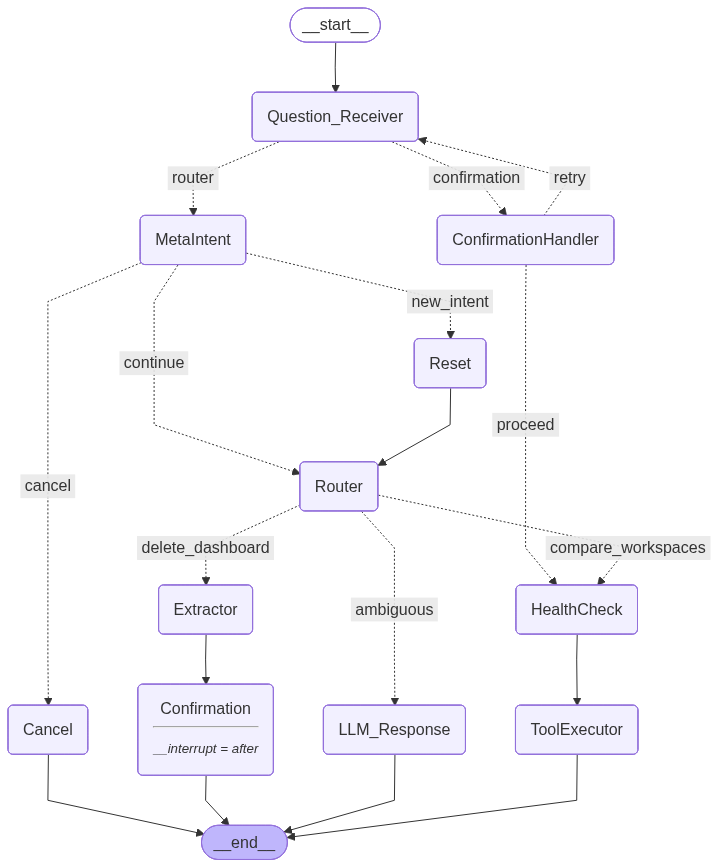

In [61]:
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

In [62]:
thread = {"configurable": {"thread_id": "3"}}
response = agent.invoke(
    {
        "messages": [
            SystemMessage(content=system_prompt),
            HumanMessage(
                content="Hi how can you assist me today?")
        ]
    },
    config=thread
    )

print(response["messages"][-1].content)

Hi there! I'm here to help you with anything related to Power BI, like migrating dashboards, deleting them, and more. How can I assist you with Power BI today?


In [63]:
response

{'messages': [SystemMessage(content='\n        You are a helpful assistant specialized in Power BI operations.\n\n        Your capabilities include:\n        - Recommending Power BI dashboards based on user queries\n        - Migrating dashboards between workspaces (Dev → Prod)\n        - Deleting dashboards from Dev and Prod workspaces\n        - Comparing dashboards between Dev and Prod workspaces\n\n        Workspace Rules:\n        - Valid workspace names are "Dev" and "Prod"\n        - Normalize any user input (e.g., DEV, dev, PROD, prod) to "Dev" or "Prod"\n\n        Tool Usage Guidelines:\n        - Select the most appropriate tool based on the user’s intent\n        - Ensure actions like migration or deletion are clearly understood before execution\n\n        Clarification Handling:\n        - If the user query is unclear, ask up to 3 relevant clarifying questions\n        - If the intent is still unclear after clarification, respond with:\n        "Sorry, not able to understan

In [64]:
# thread = {"configurable": {"thread_id": "3"}}
response = agent.invoke(
    {
        "messages": [
            SystemMessage(content=system_prompt),
            HumanMessage(
                content="i have to delete the Sales-dashboard from prod?")
        ]
    },
    config=thread
    )

print(response["messages"][-1].content)


I understood your request as Deletion:

- Dashboard: Sales-dashboard
- Workspace: Prod

👉 Reply **yes** to proceed or correct me.



In [75]:
response

{'messages': [SystemMessage(content='\n        You are a helpful assistant specialized in Power BI operations.\n\n        Your capabilities include:\n        - Recommending Power BI dashboards based on user queries\n        - Migrating dashboards between workspaces (Dev → Prod)\n        - Deleting dashboards from Dev and Prod workspaces\n        - Comparing dashboards between Dev and Prod workspaces\n\n        Workspace Rules:\n        - Valid workspace names are "Dev" and "Prod"\n        - Normalize any user input (e.g., DEV, dev, PROD, prod) to "Dev" or "Prod"\n\n        Tool Usage Guidelines:\n        - Select the most appropriate tool based on the user’s intent\n        - Ensure actions like migration or deletion are clearly understood before execution\n\n        Clarification Handling:\n        - If the user query is unclear, ask up to 3 relevant clarifying questions\n        - If the intent is still unclear after clarification, respond with:\n        "Sorry, not able to understan

In [76]:
# thread = {"configurable": {"thread_id": "3"}}
response = agent.invoke(
    {
        "messages": [
            
            HumanMessage(
                content="Sorry, i want to migrate Sales-Dashboard from dev to prod")
        ]
    },
    config=thread
    )

print(response["messages"][-1].content)


I understood your request as Migration:

- Dashboard: Sales-Dashboard
- From: Dev
- To: Prod

👉 Reply **yes** to proceed or correct me.



In [77]:
response

{'messages': [SystemMessage(content='\n        You are a helpful assistant specialized in Power BI operations.\n\n        Your capabilities include:\n        - Recommending Power BI dashboards based on user queries\n        - Migrating dashboards between workspaces (Dev → Prod)\n        - Deleting dashboards from Dev and Prod workspaces\n        - Comparing dashboards between Dev and Prod workspaces\n\n        Workspace Rules:\n        - Valid workspace names are "Dev" and "Prod"\n        - Normalize any user input (e.g., DEV, dev, PROD, prod) to "Dev" or "Prod"\n\n        Tool Usage Guidelines:\n        - Select the most appropriate tool based on the user’s intent\n        - Ensure actions like migration or deletion are clearly understood before execution\n\n        Clarification Handling:\n        - If the user query is unclear, ask up to 3 relevant clarifying questions\n        - If the intent is still unclear after clarification, respond with:\n        "Sorry, not able to understan

In [78]:
response = agent.invoke(
    {
        "messages": [
            
            HumanMessage(
                content="yes")
        ]
    },
    config=thread
    )

print(response["messages"][-1].content)

{'status': 'success', 'data': {'dataset_id': '09a5fd31-464a-4292-8548-10c2e66aa56b', 'report_id': '57dc2a3a-753b-40c3-8166-cd9a9ba2aa46', 'status': 'Sucess'}}


In [79]:
response = agent.invoke(
    {
        "messages": [
            
            HumanMessage(
                content="I need to delete the latest uploaded dashboard from prod")
        ]
    },
    config=thread
    )

print(response["messages"][-1].content)


⚠️ Missing required details for deletion.

Please provide:
dashboard_name, workspace

Example:
Sales-Dashboard, Prod



In [80]:
response = agent.invoke(
    {
        "messages": [
            
            HumanMessage(
                content="Sales-Dashboard, Prod")
        ]
    },
    config=thread
    )

print(response["messages"][-1].content)


I understood your request as Deletion:

- Dashboard: Sales-Dashboard
- Workspace: Prod

👉 Reply **yes** to proceed or correct me.



In [81]:
response

{'messages': [SystemMessage(content='\n        You are a helpful assistant specialized in Power BI operations.\n\n        Your capabilities include:\n        - Recommending Power BI dashboards based on user queries\n        - Migrating dashboards between workspaces (Dev → Prod)\n        - Deleting dashboards from Dev and Prod workspaces\n        - Comparing dashboards between Dev and Prod workspaces\n\n        Workspace Rules:\n        - Valid workspace names are "Dev" and "Prod"\n        - Normalize any user input (e.g., DEV, dev, PROD, prod) to "Dev" or "Prod"\n\n        Tool Usage Guidelines:\n        - Select the most appropriate tool based on the user’s intent\n        - Ensure actions like migration or deletion are clearly understood before execution\n\n        Clarification Handling:\n        - If the user query is unclear, ask up to 3 relevant clarifying questions\n        - If the intent is still unclear after clarification, respond with:\n        "Sorry, not able to understan

In [82]:
response = agent.invoke(
    {
        "messages": [
            
            HumanMessage(
                content="yes")
        ]
    },
    config=thread
    )

print(response["messages"][-1].content)

{'status': 'success', 'data': {'status': 'success', 'message': 'Report and dataset deleted successfully', 'resource_id': '57dc2a3a-753b-40c3-8166-cd9a9ba2aa46', 'Dashboard_name': 'Sales-Dashboard'}}


In [83]:
response = agent.invoke(
    {
        "messages": [
            
            HumanMessage(
                content="Looking for analysis related to supply chain pillar")
        ]
    },
    config=thread
    )

print(response["messages"][-1].content)

{'status': 'success', 'data': {'dashboards': [{'Selected_Dashboard': 'Purchase-Dashboard', 'Reason': 'The Purchase Dashboard is directly related to the supply chain pillar as it focuses on purchases and inventory, which are critical components of the supply chain. Its objective and domain align well with supply chain analysis, making it highly relevant.'}, {'Selected_Dashboard': 'Sales-Dashboard', 'Reason': 'The Sales Dashboard, while primarily focused on sales and revenue, includes supply chain as a tag, indicating its relevance to supply chain analysis. It provides insights into the sales aspect of the supply chain, which can be crucial for a comprehensive supply chain analysis.'}]}}
